# Maxico BSR Data

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [10]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [11]:
import re
from sklearn.feature_extraction.text import CountVectorizer
#from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MultipleLocator, FuncFormatter
from wordcloud import WordCloud, STOPWORDS

In [12]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [21]:
sql = f"""
SELECT * FROM vs1.amzmx_bsr_shr_daily_acc
WHERE bsr_rank_range='Top 50'
"""

df = bqclient.query(sql).to_dataframe()

In [23]:
print(df)

             bsr_ctgry      bsr_ctgry_label        asin  \
0     Bases ajustables  03. Adjustable Base  B0DNJK467X   
1     Bases ajustables  03. Adjustable Base  B0DNJK467X   
2     Bases ajustables  03. Adjustable Base  B0DNJK467X   
3     Bases ajustables  03. Adjustable Base  B0DNJK467X   
4     Bases ajustables  03. Adjustable Base  B0DNJK467X   
...                ...                  ...         ...   
2678         Colchones       01. Mattresses  B0CGWYNG3B   
2679         Colchones       01. Mattresses  B086Z81LKB   
2680         Colchones       01. Mattresses  B086Z81LKB   
2681         Colchones       01. Mattresses  B086Z81LKB   
2682         Colchones       01. Mattresses  B088P4N88T   

                                                  title  \
0     AMADA HOMEFURNISHING - Marco de cama ajustable...   
1     AMADA HOMEFURNISHING - Marco de cama ajustable...   
2     AMADA HOMEFURNISHING - Marco de cama ajustable...   
3     AMADA HOMEFURNISHING - Marco de cama ajustable...

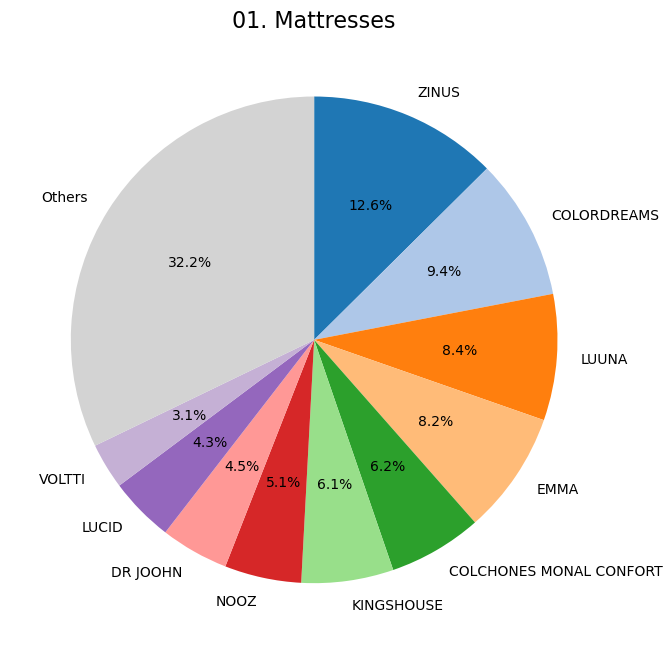

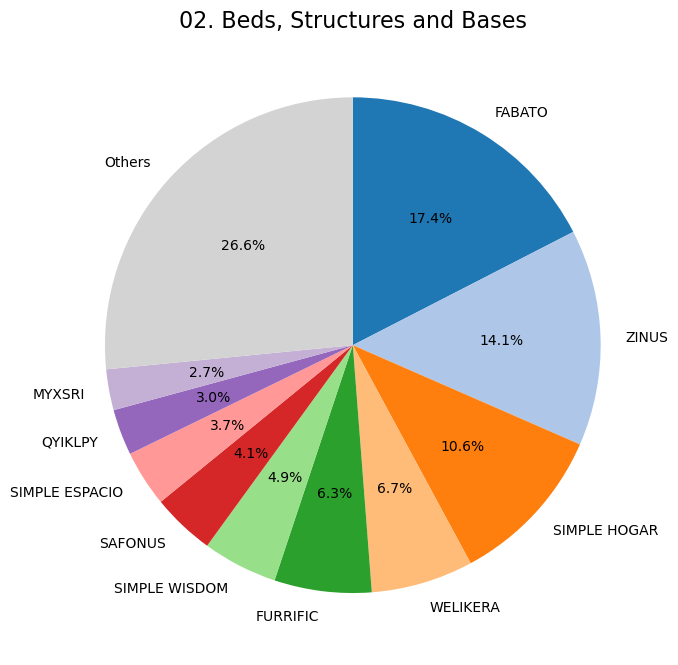

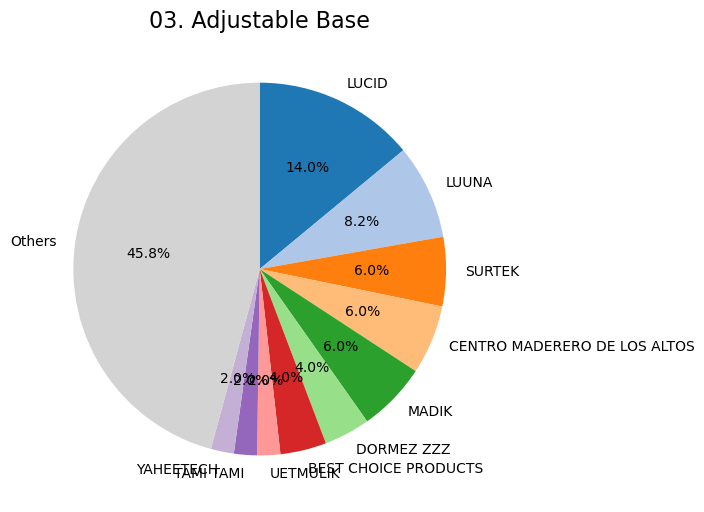

In [37]:
# 카테고리별 루프
for cat, subdf in df.groupby("bsr_ctgry_label"):
    # 브랜드별 빈도수 집계
    brand_counts = subdf['brand'].value_counts()
    
    # Top 10 브랜드 선정
    top10 = brand_counts.head(10)
    
    # Others 계산
    others = brand_counts.iloc[10:].sum()
    
    # Top 10 + Others 합치기
    if others > 0:
        top10["Others"] = others
    
    # 기본 색상 팔레트 가져오기
    base_colors = plt.cm.tab20.colors  # (20가지 색)
    
    # 색상 매핑: Others는 회색, 나머지는 기본 팔레트
    colors = []
    color_idx = 0
    for b in top10.index:
        if b == "Others":
            colors.append("lightgray")
        else:
            colors.append(base_colors[color_idx % len(base_colors)])
            color_idx += 1
    
    # 파이차트 그리기
    plt.figure(figsize=(7,7))
    plt.pie(
        top10,
        labels=top10.index,
        autopct="%.1f%%",
        startangle=90,
        counterclock=False,
        colors=colors
    )
    plt.title(f"{cat}", fontsize=16)
    plt.tight_layout()
    plt.show()